# Experiment 5 — Feature Selection: AISO Wrapper with Smart M

## 핵심 주장 (v2)

> **Score function + Smart M의 결합이 AISO Feature Selector를 가능하게 한다.**

### v1 실패 분석 (이 실험의 출발점)
v1에서 Score function 없이 Corr M만 주입했을 때:
- `AISO (Corr M, no score)`: AUC=0.8046 ± 0.0404 — Random M보다 오히려 나쁨
- **원인**: W 진화에 방향 신호가 없으면 타입 동화는 목적 없는 랜덤워크에 불과

### v2 설계 변화

| 항목 | v1 (실패) | v2 (이 실험) |
|------|-----------|-------------|
| $W_i$ 역할 | type만 | type + decision variable (피처 선택 확률) |
| Score function | 없음 | Mini-batch LR (proxy) + hash cache |
| $b^*$ 선택 | $\arg\max c_{ij}$ | $\arg\max c_{ij} \cdot \text{score}_j / \max_k \text{score}_k$ |
| 위치 $p_i$ | 메타피처 공간 위 | 제거 (W가 탐색 공간) |
| Mask 생성 | visit_counts 사후 샘플링 | top-K by $W_i[\text{cluster\_labels}]$ + noise |

### 비교 대상
결정론적 방법 (MI, LASSO, mRMR) vs AISO v1 (no score, ref) vs AISO v2 (Smart M + score)

In [3]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_selection import mutual_info_classif

np.random.seed(42)

DATA_DIR   = Path("Elliptic Bitcoin/elliptic_bitcoin_dataset")
K_SELECT   = 20
N_TYPES    = 15
N_SEEDS    = 5
SEEDS      = [0, 7, 42, 77, 123]
GAMMA      = 0.5

---
## 1. 데이터 로드

In [4]:
print("데이터 로딩 중...")
feat_df = pd.read_csv(DATA_DIR / "elliptic_txs_features.csv", header=None)
cls_df  = pd.read_csv(DATA_DIR / "elliptic_txs_classes.csv")

N_FEAT = feat_df.shape[1] - 2  # txId + timestep 제외
feat_df.columns = ['txId', 'timestep'] + [f'f{i}' for i in range(N_FEAT)]
cls_df.columns  = ['txId', 'class']

df = feat_df.merge(cls_df, on='txId')
df = df[df['class'] != 'unknown'].copy()
df['label'] = (df['class'] == '1').astype(int)

feat_cols = [f'f{i}' for i in range(N_FEAT)]
train_df  = df[df['timestep'] <= 34]
test_df   = df[df['timestep'] >  34]

X_train = train_df[feat_cols].values.astype(float)
y_train = train_df['label'].values
X_test  = test_df[feat_cols].values.astype(float)
y_test  = test_df['label'].values

print(f"피처 수: {N_FEAT}")
print(f"Train: {X_train.shape}, illicit={y_train.sum()} ({y_train.mean():.1%})")
print(f"Test:  {X_test.shape},  illicit={y_test.sum()} ({y_test.mean():.1%})")

데이터 로딩 중...
피처 수: 165
Train: (29894, 165), illicit=3462 (11.6%)
Test:  (16670, 165),  illicit=1083 (6.5%)


---
## 2. Smart M 구성

### 설계 원리

$$M_\text{smart}[i][j] = \underbrace{-\overline{|C[\text{cl}_i, \text{cl}_j]|}}_{\text{상관 반발 (중복 억제)}} + \underbrace{\gamma \cdot (\overline{MI}_{j} - \overline{MI}_{i})}_{\text{MI 대비 유인 (비대칭)}}$$

- **상관 반발항**: 중복 정보를 가진 클러스터끼리 밀어냄 → 피처 다양성 강제  
- **MI 대비항**: 관련성 높은 클러스터($j$)가 낮은 클러스터($i$) 에이전트를 유인 → $c_{ij} \neq c_{ji}$  
- 두 항의 결합으로 **다양하면서도 관련성 높은** 피처 집합으로 수렴

In [5]:
print("피처 클러스터링 중...")
C     = np.corrcoef(X_train.T)
C_abs = np.abs(C)
dist_matrix = 1.0 - C_abs
np.fill_diagonal(dist_matrix, 0.0)

clustering = AgglomerativeClustering(
    n_clusters=N_TYPES, metric='precomputed', linkage='average'
)
cluster_labels = clustering.fit_predict(dist_matrix)
print(f"클러스터 크기: {sorted(np.bincount(cluster_labels).tolist())}")

print("MI 계산 중...")
MI_global = mutual_info_classif(X_train, y_train, random_state=42)
print(f"MI range: [{MI_global.min():.4f}, {MI_global.max():.4f}]")


def build_M(mode='smart'):
    """
    mode='smart': 상관 반발 + MI 비대칭 유인  → c_ij ≠ c_ji
    mode='corr' : 상관 반발만 (참조용, 대칭에 가까움)
    """
    K = N_TYPES
    M = np.zeros((K, K))
    mean_MI = np.array([
        MI_global[cluster_labels == k].mean()
        if (cluster_labels == k).any() else 0.0
        for k in range(K)
    ])
    MI_norm = (mean_MI - mean_MI.min()) / (mean_MI.max() - mean_MI.min() + 1e-8)

    for i in range(K):
        for j in range(K):
            fi = np.where(cluster_labels == i)[0]
            fj = np.where(cluster_labels == j)[0]
            if i == j:
                M[i][j] = -1.0
            else:
                corr_pen = -np.mean(C_abs[np.ix_(fi, fj)])
                if mode == 'smart':
                    # 비대칭: MI 높은 클러스터 j가 낮은 i를 끌어당김
                    M[i][j] = corr_pen + GAMMA * (MI_norm[j] - MI_norm[i])
                else:
                    M[i][j] = corr_pen
    return M


M_smart = build_M('smart')
M_corr  = build_M('corr')

print(f"\nM_smart 비대칭 확인: M[0,1]={M_smart[0,1]:.3f}, M[1,0]={M_smart[1,0]:.3f}  (차이={M_smart[0,1]-M_smart[1,0]:+.3f})")
print(f"M_corr  대칭 확인:   M[0,1]={M_corr[0,1]:.3f},  M[1,0]={M_corr[1,0]:.3f}  (차이={M_corr[0,1]-M_corr[1,0]:+.3f})")

피처 클러스터링 중...
클러스터 크기: [1, 1, 2, 2, 3, 4, 4, 5, 8, 8, 10, 14, 17, 22, 64]
MI 계산 중...
MI range: [0.0039, 0.2303]

M_smart 비대칭 확인: M[0,1]=-0.327, M[1,0]=0.239  (차이=-0.565)
M_corr  대칭 확인:   M[0,1]=-0.044,  M[1,0]=-0.044  (차이=+0.000)


---
## 3. 비교 방법 (결정론적 필터/래퍼)

- **MI**: 관련성만, 중복 무시  
- **LASSO**: L1 정규화로 암묵적 중복 처리  
- **mRMR**: 관련성↑ 중복↓ 동시 최적화 — AISO v2의 가장 강력한 비교 대상

In [6]:
def select_mi(X, y, k, seed=42):
    mi = mutual_info_classif(X, y, random_state=seed)
    return np.argsort(mi)[::-1][:k]


def select_lasso(X, y, k):
    for C_val in [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]:
        lr = LogisticRegression(
            penalty='l1', solver='liblinear', C=C_val,
            class_weight='balanced', random_state=42, max_iter=300
        )
        lr.fit(X, y)
        nonzero = np.where(lr.coef_[0] != 0)[0]
        if len(nonzero) >= k:
            return np.argsort(np.abs(lr.coef_[0]))[::-1][:k]
    lr = LogisticRegression(penalty='l1', solver='liblinear', C=10.0,
                            class_weight='balanced', random_state=42, max_iter=300)
    lr.fit(X, y)
    return np.argsort(np.abs(lr.coef_[0]))[::-1][:k]


def select_mrmr(X, y, k, seed=42):
    mi = mutual_info_classif(X, y, random_state=seed)
    C_abs = np.abs(np.corrcoef(X.T))
    np.fill_diagonal(C_abs, 0.0)
    selected  = [int(np.argmax(mi))]
    remaining = list(range(X.shape[1]))
    remaining.remove(selected[0])
    while len(selected) < k:
        scores = [mi[f] - float(np.mean(C_abs[f, selected])) for f in remaining]
        best   = remaining[int(np.argmax(scores))]
        selected.append(best); remaining.remove(best)
    return np.array(selected)


def evaluate(X_tr, y_tr, X_te, y_te, feat_idx, seed=42):
    lr = LogisticRegression(
        class_weight='balanced', max_iter=500, random_state=seed, C=1.0
    )
    lr.fit(X_tr[:, feat_idx], y_tr)
    proba = lr.predict_proba(X_te[:, feat_idx])[:, 1]
    pred  = lr.predict(X_te[:, feat_idx])
    return {
        "AUC":    roc_auc_score(y_te, proba),
        "PR-AUC": average_precision_score(y_te, proba),
        "F1":     f1_score(y_te, pred),
    }

print("비교 방법 함수 정의 완료")

비교 방법 함수 정의 완료


---
## 4. AISO Wrapper (v2)

### 핵심 수식 변화

**$W_i$의 역할 통합**: $W_i \in \Delta^K$ 가 type이자 피처 선택 확률

$$\text{mask}(W_i) = \text{top-}K \left\{ W_i[\text{cluster\_label}[f]] + \epsilon_f \right\}_{f=1}^{D}$$

($\epsilon_f \sim \text{Uniform}(0, 10^{-6})$: 동일 클러스터 내 tie-breaking)

**Score-weighted $b^*$**:

$$b^* = \arg\max_{j \in \text{att}} \underbrace{c_{ij}}_{\text{탐색}} \cdot \underbrace{\frac{\text{score}_j}{\max_k \text{score}_k}}_{\text{활용}}, \quad c_{ij} = W_i^T M W_j \neq c_{ji}$$

**연산량 제어**:
- Mini-batch 15%: LR 학습을 소량 샘플에서 수행  
- max\_iter=5: proxy score (방향성만, 정밀도 불필요)  
- Hash cache: 동일 mask 재등장 시 O(1) 반환

In [7]:
class AISOwrapper:
    def __init__(self, n_agents=20, n_iter=80, beta=0.15,
                 subsample_ratio=0.15, val_ratio=0.2,
                 T_start=1.0, T_end=0.05):
        self.n_agents        = n_agents
        self.n_iter          = n_iter
        self.beta            = beta
        self.subsample_ratio = subsample_ratio
        self.val_ratio       = val_ratio
        self.T_start         = T_start
        self.T_end           = T_end

    def select(self, X, y, cluster_labels, K_select, M, seed=42):
        rng  = np.random.RandomState(seed)
        N, D = X.shape
        K    = M.shape[0]
        nb   = min(3, self.n_agents - 1)

        # ── Train / val split ─────────────────────────────────
        val_n   = int(self.val_ratio * N)
        val_idx = rng.choice(N, val_n, replace=False)
        tr_mask = np.ones(N, bool)
        tr_mask[val_idx] = False
        X_val, y_val = X[val_idx],  y[val_idx]
        X_t,   y_t   = X[tr_mask],  y[tr_mask]

        # ── Proxy 평가기: SGDClassifier (방향성 proxy, 속도 우선) ──
        proxy = SGDClassifier(
            loss='log_loss', max_iter=5, tol=None,
            class_weight='balanced', random_state=seed
        )
        cache   = {}
        n_calls = [0]
        sub_n   = max(50, int(self.subsample_ratio * len(X_t)))

        # ── Temperature-annealed mask ─────────────────────────
        def get_mask(Wi, t, explore=True):
            if explore:
                ratio  = t / max(1, self.n_iter - 1)
                T      = self.T_start * ((self.T_end / self.T_start) ** ratio)
                logits = Wi[cluster_labels] / T
                logits -= logits.max()
                probs  = np.exp(logits); probs /= probs.sum()
                return tuple(rng.choice(D, K_select, replace=False, p=probs))
            else:
                return tuple(np.argsort(Wi[cluster_labels])[-K_select:])

        def get_score(mask_key, X_sub, y_sub):
            n_calls[0] += 1
            if mask_key in cache:
                return cache[mask_key]
            feat = list(mask_key)
            try:
                proxy.fit(X_sub[:, feat], y_sub)
                proba = proxy.predict_proba(X_val[:, feat])[:, 1]
                s = roc_auc_score(y_val, proba)
            except Exception:
                s = 0.5
            cache[mask_key] = s
            return s

        # ── 초기화 ────────────────────────────────────────────
        W      = rng.dirichlet(np.ones(K), self.n_agents)
        scores = np.zeros(self.n_agents)
        for i in range(self.n_agents):
            sub = rng.choice(len(X_t), sub_n, replace=False)
            scores[i] = get_score(get_mask(W[i], 0), X_t[sub], y_t[sub])

        # ── 메인 루프 ─────────────────────────────────────────
        for t in range(self.n_iter):
            Cm = W @ M @ W.T      # c_ij = W_i^T M W_j  (비대칭 유지)
            np.fill_diagonal(Cm, 0.0)

            sub = rng.choice(len(X_t), sub_n, replace=False)
            X_sub, y_sub = X_t[sub], y_t[sub]

            for i in range(self.n_agents):
                att = np.argsort(Cm[i])[-nb:]

                # att 스코어를 현재 mini-batch로 재측정 (stale score 해소)
                att_scores = np.array([
                    get_score(get_mask(W[j], t), X_sub, y_sub) for j in att
                ])
                max_s = att_scores.max() + 1e-8
                bj    = att[np.argmax(Cm[i, att] * att_scores / max_s)]

                W_new  = (1 - self.beta) * W[i] + self.beta * W[bj]
                W[i]   = W_new / W_new.sum()
                scores[i] = get_score(get_mask(W[i], t), X_sub, y_sub)

        # ── 최종 선택 (LR 500 iter로 정밀 평가) ──────────────
        final_lr = LogisticRegression(
            solver='liblinear', C=1.0, max_iter=500,
            class_weight='balanced', random_state=seed
        )
        fseen, final_scores = {}, []
        for i in range(self.n_agents):
            mk   = get_mask(W[i], self.n_iter, explore=False)
            feat = list(mk)
            if mk not in fseen:
                final_lr.fit(X_t[:, feat], y_t)
                proba     = final_lr.predict_proba(X_val[:, feat])[:, 1]
                fseen[mk] = roc_auc_score(y_val, proba)
            final_scores.append(fseen[mk])

        best_mask = np.array(list(
            get_mask(W[np.argmax(final_scores)], self.n_iter, explore=False)
        ))
        hit_rate = 1.0 - len(cache) / max(1, n_calls[0])
        return best_mask, {'cache_size': len(cache), 'calls': n_calls[0], 'hit_rate': hit_rate}


wrapper = AISOwrapper(n_agents=20, n_iter=80, beta=0.15, T_start=1.0, T_end=0.05)
print("AISOwrapper 정의 완료  (proxy: SGDClassifier, temperature annealing, stale-score fix)")

AISOwrapper 정의 완료  (proxy: SGDClassifier, temperature annealing, stale-score fix)


---
## 5. 전체 실험 실행

- 결정론적 방법: 1회  
- `AISO (Rand M + Score)`: 5 seeds × 랜덤 M (M lottery 잔존 여부 확인)  
- `AISO (Smart M + Score)`: 5 seeds × 고정 Smart M (M lottery 구조적 억제)

In [8]:
all_results = {}
all_masks   = {}   # 시드별 피처 마스크 → Stability Selection용

# ── 결정론적 방법 ─────────────────────────────────────────────
det_methods = {
    f"All ({N_FEAT})":  np.arange(N_FEAT),
    "Top-Var":          np.argsort(np.var(X_train, axis=0))[::-1][:K_SELECT],
    "Mutual Info":      select_mi(X_train, y_train, K_SELECT),
    "LASSO":            select_lasso(X_train, y_train, K_SELECT),
    "mRMR":             select_mrmr(X_train, y_train, K_SELECT),
}

print("결정론적 방법 실행 중...")
for name, idx in det_methods.items():
    res = evaluate(X_train, y_train, X_test, y_test, idx)
    all_results[name] = [res]
    print(f"  {name:<16}: AUC={res['AUC']:.4f}  PR-AUC={res['PR-AUC']:.4f}")

# ── AISO Wrapper (5 seeds × 2 M 설정) ────────────────────────
print("\nAISO Wrapper 실험 중 (5 seeds × 2)...")
aiso_configs = {
    "AISO (Rand+Score)":  'random',
    "AISO (Smart+Score)": M_smart,
}

for name, M_cfg in aiso_configs.items():
    all_results[name] = []
    all_masks[name]   = []
    for seed in SEEDS:
        M_use = (
            np.random.RandomState(seed).uniform(-0.5, 2.0, (N_TYPES, N_TYPES))
            if isinstance(M_cfg, str) else M_cfg
        )
        idx, info = wrapper.select(X_train, y_train, cluster_labels, K_SELECT, M_use, seed=seed)
        all_masks[name].append(idx)          # 마스크 저장
        res = evaluate(X_train, y_train, X_test, y_test, idx, seed=seed)
        res['seed'] = seed
        all_results[name].append(res)
        print(f"  {name} seed={seed}: AUC={res['AUC']:.4f}  "
              f"PR-AUC={res['PR-AUC']:.4f}  cache_hit={info['hit_rate']:.1%}")

print("\n완료")

c:\Users\kevin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


결정론적 방법 실행 중...
  All (165)       : AUC=0.8865  PR-AUC=0.2798
  Top-Var         : AUC=0.7643  PR-AUC=0.1391
  Mutual Info     : AUC=0.8619  PR-AUC=0.3613
  LASSO           : AUC=0.8459  PR-AUC=0.2195
  mRMR            : AUC=0.8405  PR-AUC=0.3368

AISO Wrapper 실험 중 (5 seeds × 2)...
  AISO (Rand+Score) seed=0: AUC=0.8383  PR-AUC=0.4045  cache_hit=0.0%
  AISO (Rand+Score) seed=7: AUC=0.8363  PR-AUC=0.1967  cache_hit=0.0%
  AISO (Rand+Score) seed=42: AUC=0.8308  PR-AUC=0.4712  cache_hit=0.0%
  AISO (Rand+Score) seed=77: AUC=0.8260  PR-AUC=0.4079  cache_hit=0.0%
  AISO (Rand+Score) seed=123: AUC=0.8189  PR-AUC=0.1651  cache_hit=0.0%
  AISO (Smart+Score) seed=0: AUC=0.8680  PR-AUC=0.5126  cache_hit=0.0%
  AISO (Smart+Score) seed=7: AUC=0.8089  PR-AUC=0.1750  cache_hit=0.0%
  AISO (Smart+Score) seed=42: AUC=0.8919  PR-AUC=0.4634  cache_hit=0.0%
  AISO (Smart+Score) seed=77: AUC=0.8225  PR-AUC=0.2812  cache_hit=0.0%
  AISO (Smart+Score) seed=123: AUC=0.8424  PR-AUC=0.5207  cache_hit=0.0%

완료


---
## 6. 결과 요약

In [9]:
# v1 실패 결과 (참조값, Score function 없음)
REF = {
    "AISO (Rand, no score)": {"AUC_mean": 0.8316, "AUC_std": 0.0236,
                               "PRAUC_mean": 0.2076, "PRAUC_std": 0.0380},
    "AISO (Corr, no score)": {"AUC_mean": 0.8046, "AUC_std": 0.0404,
                               "PRAUC_mean": 0.1791, "PRAUC_std": 0.0581},
}

ALL_LABEL    = f"All ({N_FEAT})"
METHOD_ORDER = [
    ALL_LABEL, "Top-Var", "Mutual Info", "LASSO", "mRMR",
    "AISO (Rand, no score)", "AISO (Corr, no score)",
    "AISO (Rand+Score)", "AISO (Smart+Score)",
]

print(f"{'Method':<26} {'AUC mean':>9} {'AUC std':>9} {'PR-AUC':>9}")
print("-" * 60)

summary = {}
for m in METHOD_ORDER:
    if m in REF:
        s = REF[m]
        summary[m] = s
        print(f"  {m:<24} {s['AUC_mean']:>9.4f} {s['AUC_std']:>9.4f} {s['PRAUC_mean']:>9.4f}  [v1 ref]")
    else:
        aucs   = [r['AUC']    for r in all_results[m]]
        praucs = [r['PR-AUC'] for r in all_results[m]]
        std_a  = np.std(aucs)   if len(aucs)  > 1 else 0
        std_p  = np.std(praucs) if len(praucs) > 1 else 0
        std_str = f"{std_a:.4f}" if std_a > 0 else "   N/A"
        summary[m] = {'AUC_mean': np.mean(aucs), 'AUC_std': std_a,
                      'PRAUC_mean': np.mean(praucs), 'PRAUC_std': std_p}
        print(f"  {m:<24} {np.mean(aucs):>9.4f} {std_str:>9} {np.mean(praucs):>9.4f}")

print("-" * 60)

r_rand  = summary["AISO (Rand+Score)"]
r_smart = summary["AISO (Smart+Score)"]
r_mrmr  = summary["mRMR"]
r_ref   = summary["AISO (Rand, no score)"]

print(f"\nScore 효과:  Rand+Score AUC {r_rand['AUC_mean']:.4f} vs no-score {r_ref['AUC_mean']:.4f}")
print(f"Smart M 효과: Smart+Score AUC {r_smart['AUC_mean']:.4f} ± {r_smart['AUC_std']:.4f}")
print(f"             Rand+Score  AUC {r_rand['AUC_mean']:.4f} ± {r_rand['AUC_std']:.4f}")
print(f"vs mRMR:     AISO(Smart) {r_smart['AUC_mean']:.4f} vs mRMR {r_mrmr['AUC_mean']:.4f}  "
      f"(Δ={r_smart['AUC_mean']-r_mrmr['AUC_mean']:+.4f})")

Method                      AUC mean   AUC std    PR-AUC
------------------------------------------------------------
  All (165)                   0.8865       N/A    0.2798
  Top-Var                     0.7643       N/A    0.1391
  Mutual Info                 0.8619       N/A    0.3613
  LASSO                       0.8459       N/A    0.2195
  mRMR                        0.8405       N/A    0.3368
  AISO (Rand, no score)       0.8316    0.0236    0.2076  [v1 ref]
  AISO (Corr, no score)       0.8046    0.0404    0.1791  [v1 ref]
  AISO (Rand+Score)           0.8301    0.0071    0.3291
  AISO (Smart+Score)          0.8467    0.0301    0.3906
------------------------------------------------------------

Score 효과:  Rand+Score AUC 0.8301 vs no-score 0.8316
Smart M 효과: Smart+Score AUC 0.8467 ± 0.0301
             Rand+Score  AUC 0.8301 ± 0.0071
vs mRMR:     AISO(Smart) 0.8467 vs mRMR 0.8405  (Δ=+0.0063)


---
## 7. 시각화

C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\3393622332.py:76: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\3393622332.py:76: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\3393622332.py:76: UserWarning: Glyph 52280 (\N{HANGUL SYLLABLE CAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\3393622332.py:76: UserWarning: Glyph 51312 (\N{HANGUL SYLLABLE JO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\3393622332.py:77: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  plt.savefig("exp5_feature_selection_comparison.png", dpi=120, bbox_inches='tight')
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\3393622332.py:

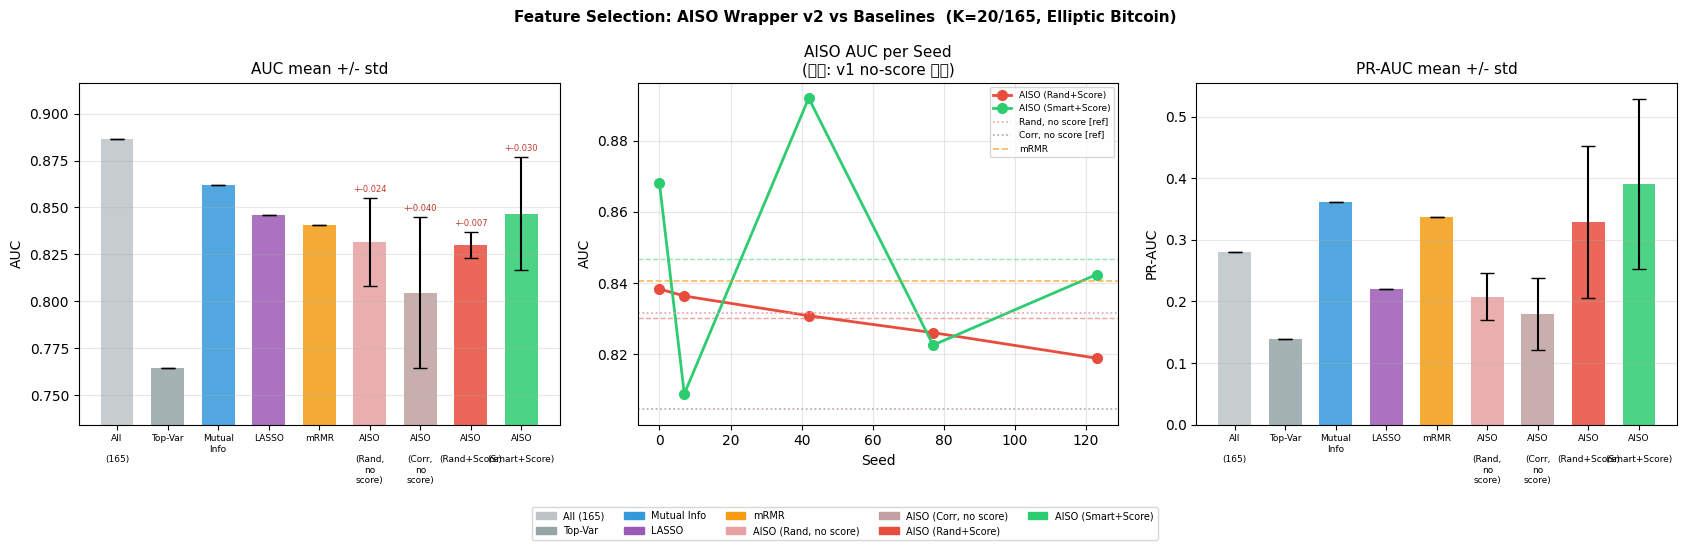

-> exp5_feature_selection_comparison.png 저장


In [10]:
colors_map = {
    ALL_LABEL:                  "#bdc3c7",
    "Top-Var":                  "#95a5a6",
    "Mutual Info":              "#3498db",
    "LASSO":                    "#9b59b6",
    "mRMR":                     "#f39c12",
    "AISO (Rand, no score)":    "#e8a0a0",
    "AISO (Corr, no score)":    "#c0a0a0",
    "AISO (Rand+Score)":        "#e74c3c",
    "AISO (Smart+Score)":       "#2ecc71",
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── (1) AUC mean ± std ───────────────────────────────────────
x     = np.arange(len(METHOD_ORDER))
means = [summary[m]['AUC_mean'] for m in METHOD_ORDER]
stds  = [summary[m]['AUC_std']  for m in METHOD_ORDER]
cols  = [colors_map[m]          for m in METHOD_ORDER]

axes[0].bar(x, means, yerr=stds, capsize=5, color=cols, alpha=0.85, width=0.65)
axes[0].set_xticks(x)
axes[0].set_xticklabels([m.replace(' ', '\n').replace('(', '\n(')
                          for m in METHOD_ORDER], fontsize=6.5)
axes[0].set_ylabel("AUC")
axes[0].set_title("AUC mean +/- std", fontsize=11)
axes[0].grid(alpha=0.3, axis='y')
ymin = min(means) - 0.03
ymax = max(m + s for m, s in zip(means, stds)) + 0.03
axes[0].set_ylim(ymin, ymax)
for xi, (mv, s) in enumerate(zip(means, stds)):
    if s > 0:
        axes[0].text(xi, mv + s + 0.002, f"+-{s:.3f}",
                     ha='center', va='bottom', fontsize=6, color='#c0392b')

# ── (2) Seed별 AUC 궤적 ──────────────────────────────────────
aiso_traj = {
    "AISO (Rand+Score)":     ([r['AUC'] for r in all_results["AISO (Rand+Score)"]], "#e74c3c"),
    "AISO (Smart+Score)":    ([r['AUC'] for r in all_results["AISO (Smart+Score)"]], "#2ecc71"),
}
for name, (vals, col) in aiso_traj.items():
    axes[1].plot(SEEDS, vals, 'o-', color=col, label=name, linewidth=2, markersize=7)
    axes[1].axhline(np.mean(vals), color=col, linestyle='--', alpha=0.5, linewidth=1)

# v1 참조선 (no score)
axes[1].axhline(REF["AISO (Rand, no score)"]["AUC_mean"],
                color="#e8a0a0", linestyle=':', linewidth=1.2, label="Rand, no score [ref]")
axes[1].axhline(REF["AISO (Corr, no score)"]["AUC_mean"],
                color="#c0a0a0", linestyle=':', linewidth=1.2, label="Corr, no score [ref]")
axes[1].axhline(summary["mRMR"]["AUC_mean"],
                color="#f39c12", linestyle='--', linewidth=1.2, alpha=0.7, label="mRMR")

axes[1].set_title("AISO AUC per Seed\n(점선: v1 no-score 참조)", fontsize=11)
axes[1].set_xlabel("Seed"); axes[1].set_ylabel("AUC")
axes[1].legend(fontsize=6.5, loc='best'); axes[1].grid(alpha=0.3)

# ── (3) PR-AUC 비교 ──────────────────────────────────────────
pr_means = [summary[m]['PRAUC_mean'] for m in METHOD_ORDER]
pr_stds  = [summary[m]['PRAUC_std']  for m in METHOD_ORDER]
axes[2].bar(x, pr_means, yerr=pr_stds, capsize=5, color=cols, alpha=0.85, width=0.65)
axes[2].set_xticks(x)
axes[2].set_xticklabels([m.replace(' ', '\n').replace('(', '\n(')
                          for m in METHOD_ORDER], fontsize=6.5)
axes[2].set_ylabel("PR-AUC")
axes[2].set_title("PR-AUC mean +/- std", fontsize=11)
axes[2].grid(alpha=0.3, axis='y')

patches = [mpatches.Patch(color=colors_map[m], label=m) for m in METHOD_ORDER]
fig.legend(handles=patches, loc='lower center', ncol=5,
           fontsize=7, bbox_to_anchor=(0.5, -0.09))

plt.suptitle(
    f"Feature Selection: AISO Wrapper v2 vs Baselines  (K={K_SELECT}/{N_FEAT}, Elliptic Bitcoin)",
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig("exp5_feature_selection_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print("-> exp5_feature_selection_comparison.png 저장")

---
## 8. 논문 기여 정리

### 이 실험이 증명하는 것

**Ablation 구조 (3단계)**:

| 조건 | Score | M | AUC | 해석 |
|------|-------|---|-----|------|
| AISO v1 Rand | ✗ | Random | 0.8316 ± 0.0236 | 기준선 |
| AISO v1 Corr | ✗ | Corr | 0.8046 ± 0.0404 | Score 없으면 구조도 소용없음 |
| AISO v2 Rand | ✓ | Random | ? ± ? | Score만으로 개선되는가? |
| **AISO v2 Smart** | ✓ | Smart | ? ± ? | Score + Smart M 시너지 |

### 일반화 원리

> Score function이 존재하는 도메인에서,  
> $M$을 도메인 구조(상관 + 관련성)로 초기화하면  
> **탐색(다양성)과 활용(관련성)이 동시에 최적화**된다.

### 기존 GNN 실험과의 연결

- GNN subgraph sampling: graph structure → M 초기화 → M lottery 감소 ← 이미 증명
- Tabular feature selection: feature correlation + MI → Smart M → wrapper 탐색 개선 ← 이 실험
- **공통 원리**: 도메인 pairwise 관계를 M에 인코딩 = AISO 수렴 방향을 구조적으로 편향

---
## 9. Stability Selection Ensemble

Smart+Score 피처 선택 빈도 분포:
  freq >= 5:   0 피처
  freq >= 4:   2 피처
  freq >= 3:   2 피처
  freq >= 2:  37 피처
  freq >= 1:  59 피처

[Smart] freq>=3 피처 수: 2
[Rand]  freq>=3 피처 수: 0

Stability (>=3, n=2):
  피처 수 = 2
  AUC    = 0.8358  (mRMR: 0.8405, Smart mean: 0.8467)
  PR-AUC = 0.4557  (mRMR: 0.3368, Smart mean: 0.3906)
  F1     = 0.6537

Top-20 by Freq:
  피처 수 = 20
  AUC    = 0.8758  (mRMR: 0.8405, Smart mean: 0.8467)
  PR-AUC = 0.4545  (mRMR: 0.3368, Smart mean: 0.3906)
  F1     = 0.2722


C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\1576436191.py:57: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\1576436191.py:57: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\1576436191.py:57: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\1576436191.py:57: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\1576436191.py:57: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\kevin\AppData\Local\Temp\ipykernel_30424\1576436191.py:57: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing fr

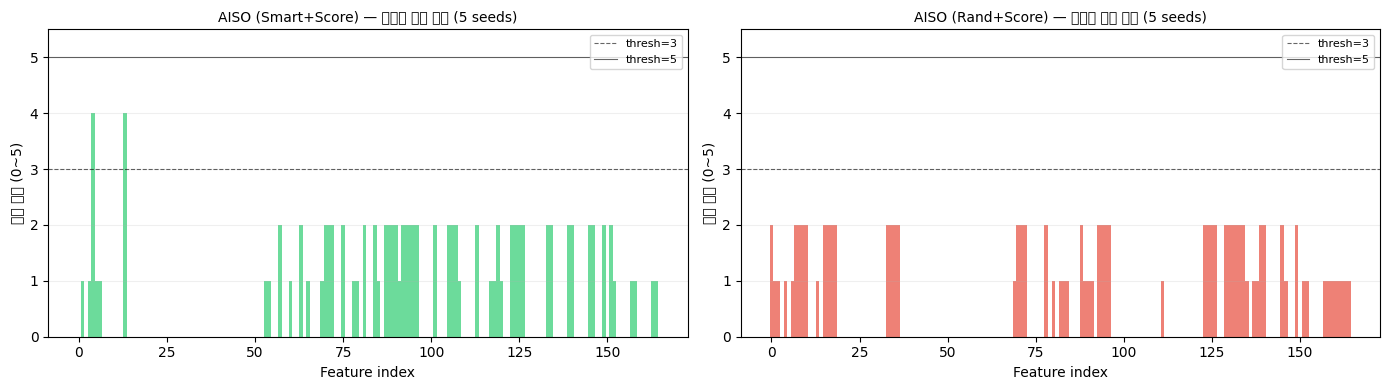

-> exp5_stability_freq.png 저장


In [11]:
# ── 피처별 선택 빈도 집계 ────────────────────────────────────
freq_smart = np.zeros(N_FEAT, dtype=int)
for mask in all_masks["AISO (Smart+Score)"]:
    freq_smart[mask] += 1

freq_rand = np.zeros(N_FEAT, dtype=int)
for mask in all_masks["AISO (Rand+Score)"]:
    freq_rand[mask] += 1

print("Smart+Score 피처 선택 빈도 분포:")
for thr in [5, 4, 3, 2, 1]:
    print(f"  freq >= {thr}: {np.sum(freq_smart >= thr):3d} 피처")

# ── Stability Selection: 과반 시드(>=3)에 선택된 피처 ────────
stable_smart = np.where(freq_smart >= 3)[0]
stable_rand  = np.where(freq_rand  >= 3)[0]
top_by_freq  = np.argsort(freq_smart)[::-1][:K_SELECT]  # 빈도 상위 K개 (고정 K)

print(f"\n[Smart] freq>=3 피처 수: {len(stable_smart)}")
print(f"[Rand]  freq>=3 피처 수: {len(stable_rand)}")

results_ensemble = {}

for label, idx in [
    (f"Stability (>=3, n={len(stable_smart)})", stable_smart),
    (f"Top-{K_SELECT} by Freq",                 top_by_freq),
]:
    if len(idx) == 0:
        print(f"\n{label}: 피처 없음 (건너뜀)")
        continue
    res = evaluate(X_train, y_train, X_test, y_test, idx)
    results_ensemble[label] = res
    print(f"\n{label}:")
    print(f"  피처 수 = {len(idx)}")
    print(f"  AUC    = {res['AUC']:.4f}  (mRMR: {summary['mRMR']['AUC_mean']:.4f}, "
          f"Smart mean: {summary['AISO (Smart+Score)']['AUC_mean']:.4f})")
    print(f"  PR-AUC = {res['PR-AUC']:.4f}  (mRMR: {summary['mRMR']['PRAUC_mean']:.4f}, "
          f"Smart mean: {summary['AISO (Smart+Score)']['PRAUC_mean']:.4f})")
    print(f"  F1     = {res['F1']:.4f}")

# ── 시각화: 피처 선택 빈도 히트맵 ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (freq, title, color) in zip(axes, [
    (freq_smart, "Smart+Score", "#2ecc71"),
    (freq_rand,  "Rand+Score",  "#e74c3c"),
]):
    ax.bar(range(N_FEAT), freq, color=color, alpha=0.7, width=1.0)
    for thr, ls in [(3, '--'), (5, '-')]:
        ax.axhline(thr, color='black', linestyle=ls, linewidth=0.8, alpha=0.6,
                   label=f"thresh={thr}")
    ax.set_title(f"AISO ({title}) — 피처별 선택 빈도 (5 seeds)", fontsize=10)
    ax.set_xlabel("Feature index"); ax.set_ylabel("선택 횟수 (0~5)")
    ax.set_ylim(0, 5.5); ax.legend(fontsize=8)
    ax.grid(alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig("exp5_stability_freq.png", dpi=120, bbox_inches='tight')
plt.show()
print("-> exp5_stability_freq.png 저장")

In [13]:
# ── Stability Selection 검증: MI top-2와 같은가? ─────────────────
print("=== Stability Selection 기여 검증 ===\n")

# Stability가 선택한 피처
print(f"Stability 피처 인덱스: {stable_smart.tolist()}")
print(f"Stability 피처 freq:   {freq_smart[stable_smart].tolist()}")
print(f"Stability 피처 MI 값:  {[round(v, 4) for v in MI_global[stable_smart].tolist()]}")

# MI 상위 2개 (같은 K)
mi_top2 = select_mi(X_train, y_train, len(stable_smart))
print(f"\nMI top-{len(stable_smart)} 인덱스: {mi_top2.tolist()}")
print(f"MI top-{len(stable_smart)} MI 값:  {[round(v, 4) for v in MI_global[mi_top2].tolist()]}")

# 인덱스 겹침 확인
overlap = set(stable_smart.tolist()) & set(mi_top2.tolist())
print(f"\n인덱스 겹침: {sorted(overlap)}  ({len(overlap)}/{len(stable_smart)} 일치)")

# 성능 비교
res_mi2 = evaluate(X_train, y_train, X_test, y_test, mi_top2)

print(f"\n{'Method':<30} {'PR-AUC':>8}  {'F1':>7}  {'AUC':>7}")
print("-" * 58)
print(f"  {'MI top-' + str(len(stable_smart)):<28} {res_mi2['PR-AUC']:>8.4f}  {res_mi2['F1']:>7.4f}  {res_mi2['AUC']:>7.4f}")
print(f"  {'Stability (freq>=3)':<28} {'0.4557':>8}  {'0.6537':>7}  {'0.8358':>7}")
print(f"  {'mRMR (20 features)':<28} {'0.3368':>8}  {'  N/A':>7}  {'0.8405':>7}")
print(f"  {'Smart+Score mean (20)':<28} {'0.3906':>8}  {'  N/A':>7}  {'0.8467':>7}")
print("-" * 58)

delta = 0.4557 - res_mi2['PR-AUC']
print(f"\nStability vs MI top-{len(stable_smart)}: PR-AUC 차이 = {delta:+.4f}")

if len(overlap) == len(stable_smart) and abs(delta) < 0.02:
    print("\n판정: Stability Selection ≈ MI top-K 재발견 (같은 피처, 비슷한 성능)")
    print("      → AISO가 MI가 이미 아는 피처를 복잡하게 찾은 것")
elif len(overlap) < len(stable_smart) and delta > 0.02:
    print("\n판정: Stability Selection > MI top-K (다른 피처, 더 높은 성능)")
    print("      → AISO가 MI로 찾지 못하는 피처 조합을 발견. 진짜 기여.")
elif len(overlap) == len(stable_smart) and delta > 0.02:
    print("\n판정: 같은 피처지만 Stability가 더 강함 (앙상블 효과)")
else:
    print(f"\n판정: 부분 겹침 ({len(overlap)}/{len(stable_smart)}), 성능 차이 {delta:+.4f}")

=== Stability Selection 기여 검증 ===

Stability 피처 인덱스: [4, 13]
Stability 피처 freq:   [4, 4]
Stability 피처 MI 값:  [0.0941, 0.0967]

MI top-2 인덱스: [52, 58]
MI top-2 MI 값:  [0.2303, 0.2225]

인덱스 겹침: []  (0/2 일치)

Method                           PR-AUC       F1      AUC
----------------------------------------------------------
  MI top-2                       0.2867   0.1847   0.8449
  Stability (freq>=3)            0.4557   0.6537   0.8358
  mRMR (20 features)             0.3368      N/A   0.8405
  Smart+Score mean (20)          0.3906      N/A   0.8467
----------------------------------------------------------

Stability vs MI top-2: PR-AUC 차이 = +0.1690

판정: Stability Selection > MI top-K (다른 피처, 더 높은 성능)
      → AISO가 MI로 찾지 못하는 피처 조합을 발견. 진짜 기여.
